            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

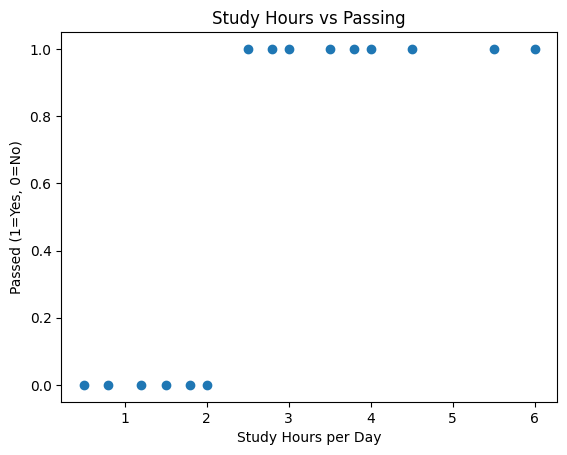

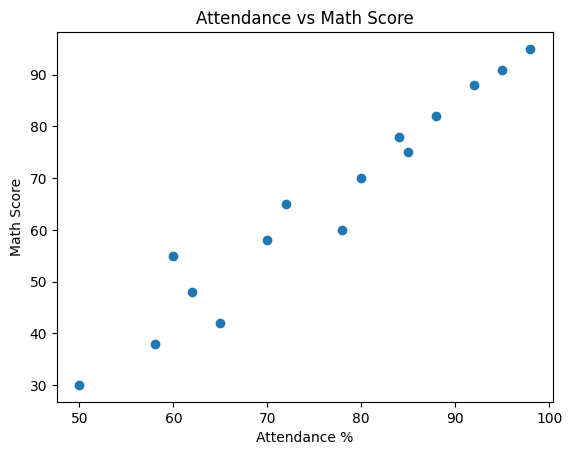

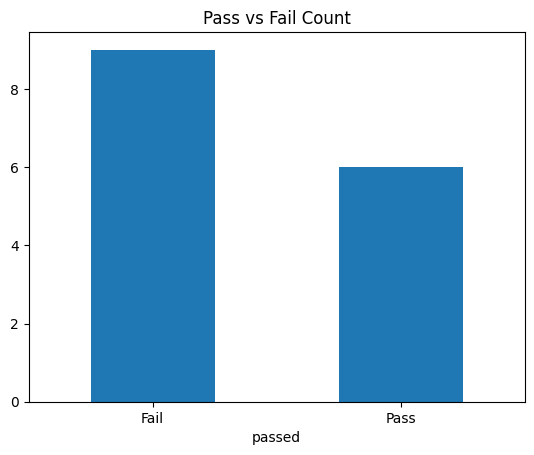

Model Accuracy: 1.0
Prediction (1=Pass, 0=Fail): 1


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "name": ["Alice","Bob","Charlie","Diana","Eve","Frank","Grace","Henry","Iris","Jack","Karen","Liam","Mia","Noah","Olivia"],
    "math": [88,42,75,95,38,60,55,82,70,30,65,48,91,58,78],
    "science": [92,55,70,98,42,65,48,79,74,35,60,52,94,62,75],
    "english": [76,48,80,91,50,72,44,85,68,40,70,44,88,55,82],
    "history": [80,50,68,89,45,58,52,77,65,28,62,55,92,60,70],
    "pe": [95,60,88,97,55,70,62,90,78,45,75,58,96,68,85],
    "attendance_pct": [92,65,85,98,58,78,60,88,80,50,72,62,95,70,84],
    "study_hours_per_day": [4.5,1.2,3.0,6.0,0.8,2.5,1.5,4.0,3.5,0.5,2.8,1.8,5.5,2.0,3.8],
    "passed": [1,0,1,1,0,1,0,1,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)
df.head()

print(df.describe())

print("\nPass/Fail count:")
print(df["passed"].value_counts())

plt.scatter(df["study_hours_per_day"], df["passed"])
plt.xlabel("Study Hours per Day")
plt.ylabel("Passed (1=Yes, 0=No)")
plt.title("Study Hours vs Passing")
plt.show()

plt.scatter(df["attendance_pct"], df["math"])
plt.xlabel("Attendance %")
plt.ylabel("Math Score")
plt.title("Attendance vs Math Score")
plt.show()

df["passed"].value_counts().plot(kind="bar")
plt.title("Pass vs Fail Count")
plt.xticks([0,1], ["Fail", "Pass"], rotation=0)
plt.show()

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[["math", "science", "english", "history", "attendance_pct", "study_hours_per_day"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

sample = pd.DataFrame([[80, 85, 78, 75, 90, 4]],
                      columns=["math", "science", "english", "history", "attendance_pct", "study_hours_per_day"])

prediction = model.predict(sample)

print("Prediction (1=Pass, 0=Fail):", prediction[0])

